# 🛰️ Satellite Re-entry Decay Prediction

End-to-end machine learning pipeline: from raw data ingestion to model evaluation.

---
## 📦 Section 1 — Data Loading & Exploration (DISCOS Objects)

Load the DISCOS satellite objects dataset and explore its structure.

In [1]:
import pandas as pd

file_path = r"C:\Users\dell\Desktop\newfolder\discos_objects.csv"
df = pd.read_csv(file_path)

df.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_20616\2708425322.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,cosparId,vimpelId,satno,name,objectClass,mass,shape,width,height,depth,...,span,xSectMax,xSectMin,xSectAvg,firstEpoch,mission,predDecayDate,active,cataloguedFragments,onOrbitCataloguedFragments
0,1964-063C,NaN,900.0,Calsphere 1,Payload,0.99,Sphere,NaN,NaN,NaN,...,0.36,0.101788,0.101788,0.101788,1964-10-06,Defense Calibration,2099-04-23,True,0,0
1,1964-063E,NaN,902.0,Calsphere 2,Payload,9.71,Sphere,0.36,0.36,0.36,...,0.36,0.101800,0.101800,0.101800,1964-10-06,Defense Calibration,3214-01-03,True,0,0
2,1965-034C,NaN,1361.0,LCS 1,Payload,33.70,Sphere,1.13,1.13,1.13,...,1.13,1.002900,1.002900,1.002900,1965-05-06,Defense Calibration,9999-12-31,True,0,0
3,1965-065E,NaN,1512.0,Tempsat 1,Payload,8.92,Sphere,0.36,0.36,0.36,...,0.36,0.101800,0.101800,0.101800,1965-08-13,Defense Calibration,3386-05-06,True,0,0
4,1965-065H,NaN,1520.0,Calsphere 4,Payload,4.00,Sphere,0.40,0.40,0.40,...,0.40,0.125700,0.125700,0.125700,1965-08-13,Defense Calibration,2588-11-07,True,0,0


In [2]:
df.columns,df.info(),df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89874 entries, 0 to 89873
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cosparId                    73110 non-null  object 
 1   vimpelId                    17628 non-null  float64
 2   satno                       68257 non-null  float64
 3   name                        74713 non-null  object 
 4   objectClass                 89874 non-null  object 
 5   mass                        38993 non-null  float64
 6   shape                       38170 non-null  object 
 7   width                       22913 non-null  float64
 8   height                      37685 non-null  float64
 9   depth                       22877 non-null  float64
 10  diameter                    15319 non-null  float64
 11  span                        37338 non-null  float64
 12  xSectMax                    37928 non-null  float64
 13  xSectMin                    379

(Index(['cosparId', 'vimpelId', 'satno', 'name', 'objectClass', 'mass', 'shape',
        'width', 'height', 'depth', 'diameter', 'span', 'xSectMax', 'xSectMin',
        'xSectAvg', 'firstEpoch', 'mission', 'predDecayDate', 'active',
        'cataloguedFragments', 'onOrbitCataloguedFragments'],
       dtype='object'),
 None,
 (89874, 21))

---
## 🏷️ Section 2 — Object Class Feature Engineering

Re-categorise the fine-grained `objectClass` labels into four top-level groups: `PAYLOAD`, `ROCKET_BODY`, `DEBRIS`, and `MISSION_OBJECT`.

In [4]:
def recategorize_object_class(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.strip()
    
    if x == "Payload":
        return "PAYLOAD"
    
    elif x == "Rocket Body":
        return "ROCKET_BODY"
    
    elif x in [
        "Payload Fragmentation Debris",
        "Rocket Fragmentation Debris",
        "Payload Debris",
        "Rocket Debris",
        "Other Debris"
    ]:
        return "DEBRIS"
    
    elif x in [
        "Payload Mission Related Object",
        "Rocket Mission Related Object"
    ]:
        return "MISSION_OBJECT"
    
    else:
        return "UNKNOWN"

In [5]:
import pandas as pd

df['objectClass_grouped'] = df['objectClass'].apply(recategorize_object_class)

In [6]:
df['objectClass_grouped'].value_counts()

objectClass_grouped
DEBRIS            32275
PAYLOAD           27197
UNKNOWN           13582
ROCKET_BODY        8532
MISSION_OBJECT     8288
Name: count, dtype: int64

In [9]:
df.columns


Index(['cosparId', 'vimpelId', 'satno', 'name', 'objectClass', 'mass', 'shape',
       'width', 'height', 'depth', 'diameter', 'span', 'xSectMax', 'xSectMin',
       'xSectAvg', 'firstEpoch', 'mission', 'predDecayDate', 'active',
       'cataloguedFragments', 'onOrbitCataloguedFragments',
       'objectClass_grouped'],
      dtype='object')

---
## 🌐 Section 3 — Space-Track Decay Data Retrieval

Authenticate with the Space-Track.org API and download confirmed re-entry records (`PRECEDENCE=2`) since 2018.

In [ ]:
import requests
import pandas as pd

USERNAME = "g21.meghaj.jadhav@gnkhalsa.edu.in"
PASSWORD = "15LPAgooGLEmegh"

session = requests.Session()

login_url = "https://www.space-track.org/ajaxauth/login"

login_response = session.post(login_url, data={
    "identity": USERNAME,
    "password": PASSWORD
})

if login_response.status_code != 200:
    raise Exception("Login failed")

print("✅ Logged in successfully")



query_url = (
    "https://www.space-track.org/basicspacedata/query/class/decay/"
    "PRECEDENCE/2/"
    "DECAY_EPOCH/%3E2018-01-01/"
    "orderby/NORAD_CAT_ID/"
    "format/json"
)

response = session.get(query_url)

print("Status:", response.status_code)

# Show raw response if failure
if response.status_code != 200:
    print(response.text[:500])  # print first 500 chars
    raise Exception("Data fetch failed")

data = response.json()
print(f"✅ Retrieved {len(data)} records")



df_decay = pd.DataFrame(data)

# Keep only required columns
df_decay = df_decay[['NORAD_CAT_ID', 'DECAY_EPOCH']].copy()

# Convert to datetime
df_decay['DECAY_EPOCH'] = pd.to_datetime(df_decay['DECAY_EPOCH'])

# Remove duplicates
df_decay = df_decay.sort_values('DECAY_EPOCH')
df_decay = df_decay.drop_duplicates(subset=['NORAD_CAT_ID'], keep='last')

# Drop missing
df_decay = df_decay.dropna()

print("✅ Clean dataset ready")
print(df_decay.shape)



df_decay.to_csv("decay_clean.csv", index=False)

print("💾 Saved as decay_clean.csv")


# =========================
# 🔍 5. QUICK CHECK
# =========================
print(df_decay.head())


✅ Logged in successfully
Status: 200
✅ Retrieved 8829 records
✅ Clean dataset ready
(8829, 2)
💾 Saved as decay_clean.csv
     NORAD_CAT_ID DECAY_EPOCH
237         24969  2018-01-08
604         31207  2018-01-08
290         26172  2018-01-10
1927        41939  2018-01-11
2294        43093  2018-01-16


In [3]:
df_decay.describe()

,DECAY_EPOCH
count,8829
mean,2023-06-14 05:36:08.807339520
min,2018-01-08 00:00:00
25%,2022-05-08 00:00:00
50%,2023-06-06 00:00:00
75%,2024-11-10 00:00:00
max,2026-03-31 00:00:00


In [4]:
df_decay

,NORAD_CAT_ID,DECAY_EPOCH
237,24969,2018-01-08
604,31207,2018-01-08
290,26172,2018-01-10
1927,41939,2018-01-11
2294,43093,2018-01-16
...,...,...
3753,46533,2026-03-30
8723,63555,2026-03-31
8304,58522,2026-03-31
8297,58456,2026-03-31


---
## 📡 Section 4 — TLE History Fetching

For each decayed object, retrieve its Two-Line Element (TLE) orbital history from the 60 days leading up to decay. Two strategies are shown: per-satellite and batch fetching.

In [5]:
df_sample = df_decay.sample(50, random_state=42).reset_index(drop=True)

print(df_sample.shape)
df_sample.head()

(50, 2)


,NORAD_CAT_ID,DECAY_EPOCH
0,36265,2021-08-24
1,49482,2025-12-01
2,52944,2024-08-02
3,34277,2022-09-16
4,38232,2024-11-08


In [6]:
import time
import pandas as pd

def fetch_tle_history(session, norad_id, decay_date, days_back=60):
    
    start_date = (decay_date - pd.Timedelta(days=days_back)).strftime('%Y-%m-%d')
    end_date = decay_date.strftime('%Y-%m-%d')
    
    url = (
        "https://www.space-track.org/basicspacedata/query/class/gp_history/"
        f"NORAD_CAT_ID/{norad_id}/"
        f"EPOCH/{start_date}--{end_date}/"
        "orderby/EPOCH asc/"
        "format/json"
    )
    
    response = session.get(url)
    
    if response.status_code != 200:
        print(f"❌ Failed for {norad_id}")
        return None
    
    data = response.json()
    
    # Respect API limits
    time.sleep(1)
    
    return data

In [7]:
all_tle_data = []

for i, row in df_sample.iterrows():
    
    norad_id = int(row['NORAD_CAT_ID'])
    decay_date = row['DECAY_EPOCH']
    
    print(f"{i+1}/50 → Fetching NORAD {norad_id}")
    
    tle_data = fetch_tle_history(session, norad_id, decay_date)
    
    if tle_data is None or len(tle_data) == 0:
        continue
    
    for entry in tle_data:
        entry['NORAD_CAT_ID'] = norad_id
        entry['DECAY_EPOCH'] = decay_date
    
    all_tle_data.extend(tle_data)

1/50 → Fetching NORAD 36265
2/50 → Fetching NORAD 49482
3/50 → Fetching NORAD 52944
4/50 → Fetching NORAD 34277
5/50 → Fetching NORAD 38232
6/50 → Fetching NORAD 31403
7/50 → Fetching NORAD 49228
8/50 → Fetching NORAD 34333
9/50 → Fetching NORAD 55865
10/50 → Fetching NORAD 49684
11/50 → Fetching NORAD 50545
12/50 → Fetching NORAD 56870
13/50 → Fetching NORAD 9572
14/50 → Fetching NORAD 44238
15/50 → Fetching NORAD 51312
16/50 → Fetching NORAD 44370
17/50 → Fetching NORAD 52766
18/50 → Fetching NORAD 42910
19/50 → Fetching NORAD 51438
20/50 → Fetching NORAD 47329
21/50 → Fetching NORAD 50861
22/50 → Fetching NORAD 60215
23/50 → Fetching NORAD 49677
24/50 → Fetching NORAD 51446
25/50 → Fetching NORAD 56118
26/50 → Fetching NORAD 35336
27/50 → Fetching NORAD 56935
28/50 → Fetching NORAD 35760
29/50 → Fetching NORAD 49130
30/50 → Fetching NORAD 43097
31/50 → Fetching NORAD 46841
32/50 → Fetching NORAD 29814
33/50 → Fetching NORAD 37723
34/50 → Fetching NORAD 38470
35/50 → Fetching NORAD 4

In [8]:
df_tle = pd.DataFrame(all_tle_data)

print(df_tle.shape)
df_tle.head()

(3628, 42)


,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,...,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,DECAY_EPOCH,error
0,3.0,GENERATED VIA SPACE-TRACK.ORG API,2025-10-03T18:13:58,18 SPCS,NOAA 17 DEB,2002-032DL,EARTH,TEME,UTC,SGP4,...,2002-06-24,AFWTR,None,4831630,299116024,0 NOAA 17 DEB,1 49482U 02032DL 25276.35638610 .00295112 0...,2 49482 98.7094 307.0031 0008532 2.5665 357...,2025-12-01,NaN
1,3.0,GENERATED VIA SPACE-TRACK.ORG API,2025-10-07T17:38:49,18 SPCS,NOAA 17 DEB,2002-032DL,EARTH,TEME,UTC,SGP4,...,2002-06-24,AFWTR,None,4836461,299339283,0 NOAA 17 DEB,1 49482U 02032DL 25280.05408405 .00133353 0...,2 49482 98.7072 311.2375 0007775 343.0907 17...,2025-12-01,NaN
2,3.0,GENERATED VIA SPACE-TRACK.ORG API,2025-10-08T06:56:21,18 SPCS,NOAA 17 DEB,2002-032DL,EARTH,TEME,UTC,SGP4,...,2002-06-24,AFWTR,None,4837219,299398804,0 NOAA 17 DEB,1 49482U 02032DL 25281.04411080 .00187552 0...,2 49482 98.7072 312.3722 0007716 338.6788 21...,2025-12-01,NaN
3,3.0,GENERATED VIA SPACE-TRACK.ORG API,2025-10-08T10:51:44,18 SPCS,NOAA 17 DEB,2002-032DL,EARTH,TEME,UTC,SGP4,...,2002-06-24,AFWTR,None,4837766,299430923,0 NOAA 17 DEB,1 49482U 02032DL 25281.04411081 .00187552 0...,2 49482 98.7072 312.3723 0007716 338.6789 21...,2025-12-01,NaN
4,3.0,GENERATED VIA SPACE-TRACK.ORG API,2025-10-12T03:37:44,18 SPCS,NOAA 17 DEB,2002-032DL,EARTH,TEME,UTC,SGP4,...,2002-06-24,AFWTR,None,4844080,299854684,0 NOAA 17 DEB,1 49482U 02032DL 25284.34279885 .00119162 0...,2 49482 98.7066 316.1553 0007256 325.4699 34...,2025-12-01,NaN


In [9]:
df_tle.columns

Index(['CCSDS_OMM_VERS', 'COMMENT', 'CREATION_DATE', 'ORIGINATOR',
       'OBJECT_NAME', 'OBJECT_ID', 'CENTER_NAME', 'REF_FRAME', 'TIME_SYSTEM',
       'MEAN_ELEMENT_THEORY', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY',
       'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
       'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID',
       'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT',
       'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS',
       'OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'LAUNCH_DATE', 'SITE',
       'DECAY_DATE', 'FILE', 'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2',
       'DECAY_EPOCH', 'error'],
      dtype='object')

In [10]:
df_tle = df_tle[[
    'NORAD_CAT_ID',
    'EPOCH',
    'MEAN_MOTION',
    'MEAN_MOTION_DOT',
    'BSTAR',
    'ECCENTRICITY',
    'INCLINATION',
    'PERIAPSIS',
    'APOAPSIS',
    'DECAY_EPOCH'
]].copy()

In [11]:
df_tle['EPOCH'] = pd.to_datetime(df_tle['EPOCH'])

numeric_cols = [
    'MEAN_MOTION',
    'MEAN_MOTION_DOT',
    'BSTAR',
    'ECCENTRICITY',
    'INCLINATION',
    'PERIAPSIS',
    'APOAPSIS'
]

for col in numeric_cols:
    df_tle[col] = pd.to_numeric(df_tle[col], errors='coerce')

df_tle = df_tle.dropna(subset=[
    'MEAN_MOTION',
    'BSTAR',
    'PERIAPSIS',
    'APOAPSIS'
])

In [12]:
df_tle['days_to_decay'] = (
    df_tle['DECAY_EPOCH'] - df_tle['EPOCH']
).dt.total_seconds() / (24 * 3600)

In [13]:
print(df_tle['days_to_decay'].describe())

count    3607.000000
mean       28.921785
std        17.073379
min         0.013356
25%        14.026014
50%        28.271150
75%        43.421188
max        59.967921
Name: days_to_decay, dtype: float64


In [14]:
df_tle = df_tle.sort_values(['NORAD_CAT_ID', 'EPOCH'])

In [15]:
features = df_tle.groupby('NORAD_CAT_ID').agg({
    'MEAN_MOTION': ['last', 'std'],
    'BSTAR': ['last', 'mean', 'std'],
    'ECCENTRICITY': 'last',
    'INCLINATION': 'last',
    'PERIAPSIS': 'last',
    'APOAPSIS': 'last',
    'MEAN_MOTION_DOT': 'mean',
    'days_to_decay': 'min'
}).reset_index()

In [16]:
features.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in features.columns
]

In [17]:
features = features.rename(columns={
    'NORAD_CAT_ID': 'NORAD_CAT_ID',
    'MEAN_MOTION_last': 'mean_motion_last',
    'MEAN_MOTION_std': 'mean_motion_std',
    'BSTAR_last': 'bstar_last',
    'BSTAR_mean': 'bstar_avg',
    'BSTAR_std': 'bstar_std',
    'ECCENTRICITY_last': 'ecc_last',
    'INCLINATION_last': 'inc_last',
    'PERIAPSIS_last': 'periapsis_last',
    'APOAPSIS_last': 'apoapsis_last',
    'MEAN_MOTION_DOT_mean': 'mean_motion_dot_avg',
    'days_to_decay_min': 'target_days'
})

---
## 🚀 Section 5 — Full-Scale TLE Batch Download

Fetch TLE history for **all 8 829** decayed objects in batches of 100 to stay within API rate limits, then merge into one consolidated dataset.

In [18]:
print(features.shape)
features.head()

(27, 12)


,NORAD_CAT_ID,mean_motion_last,mean_motion_std,bstar_last,bstar_avg,bstar_std,ecc_last,inc_last,periapsis_last,apoapsis_last,mean_motion_dot_avg,target_days
0,9572,16.238223,0.158070,0.003126,0.003230,0.000707,0.000812,73.9823,203.844,214.549,0.008096,2.906710
1,31403,15.975712,0.157430,0.023078,0.007611,0.004673,0.002302,98.3116,265.835,296.489,0.007110,0.357543
2,34277,15.978143,0.127727,0.013885,0.005269,0.002793,0.002202,73.6437,265.821,295.151,0.005551,0.820921
3,34333,16.048922,0.123913,0.004881,0.002641,0.000785,0.002540,73.9842,244.029,277.760,0.004317,0.415923
4,35336,15.611283,0.131303,0.018000,0.012764,0.003764,0.001148,97.7543,376.637,392.161,0.005536,8.078423


In [19]:
df_tle.columns

Index(['NORAD_CAT_ID', 'EPOCH', 'MEAN_MOTION', 'MEAN_MOTION_DOT', 'BSTAR',
       'ECCENTRICITY', 'INCLINATION', 'PERIAPSIS', 'APOAPSIS', 'DECAY_EPOCH',
       'days_to_decay'],
      dtype='object')

In [20]:
import os
import time
import pandas as pd

def fetch_tle_history(session, norad_id, decay_date, days_back=60):
    
    start_date = (decay_date - pd.Timedelta(days=days_back)).strftime('%Y-%m-%d')
    end_date = decay_date.strftime('%Y-%m-%d')
    
    url = (
        "https://www.space-track.org/basicspacedata/query/class/gp_history/"
        f"NORAD_CAT_ID/{norad_id}/"
        f"EPOCH/{start_date}--{end_date}/"
        "orderby/EPOCH asc/"
        "format/json"
    )
    
    response = session.get(url)
    
    if response.status_code != 200:
        print(f"❌ Failed {norad_id}")
        return None
    
    time.sleep(1)  # API safety
    
    return response.json()

In [22]:
def fetch_tle_batch(session, norad_ids, start_date, end_date):
    
    ids_str = ",".join(map(str, norad_ids))
    
    url = (
        "https://www.space-track.org/basicspacedata/query/class/gp_history/"
        f"NORAD_CAT_ID/{ids_str}/"
        f"EPOCH/{start_date}--{end_date}/"
        "orderby/NORAD_CAT_ID,EPOCH asc/"
        "format/json"
    )
    
    response = session.get(url)
    
    if response.status_code != 200:
        print("❌ Batch failed")
        return None
    
    time.sleep(2)  # slightly higher, but far fewer calls
    
    return response.json()

In [23]:
batch_size = 100
output_dir = "tle_batches"

os.makedirs(output_dir, exist_ok=True)

for start in range(0, len(df_decay), batch_size):
    
    end = start + batch_size
    batch = df_decay.iloc[start:end]
    
    print(f"\n🚀 Processing batch {start} → {end}")
    
    norad_ids = batch['NORAD_CAT_ID'].astype(int).tolist()
    
    # 🔥 Use global date window (simpler & faster)
    start_date = (batch['DECAY_EPOCH'].min() - pd.Timedelta(days=60)).strftime('%Y-%m-%d')
    end_date = batch['DECAY_EPOCH'].max().strftime('%Y-%m-%d')
    
    tle_data = fetch_tle_batch(session, norad_ids, start_date, end_date)
    
    if not tle_data:
        continue
    
    df_batch = pd.DataFrame(tle_data)
    
    # Merge decay info back
    df_batch = df_batch.merge(
        batch[['NORAD_CAT_ID', 'DECAY_EPOCH']],
        on='NORAD_CAT_ID',
        how='left'
    )
    
    file_path = f"{output_dir}/batch_{start}_{end}.csv"
    df_batch.to_csv(file_path, index=False)
    
    print(f"✅ Saved {file_path} ({len(df_batch)} rows)")


🚀 Processing batch 0 → 100
✅ Saved tle_batches/batch_0_100.csv (25721 rows)

🚀 Processing batch 100 → 200
✅ Saved tle_batches/batch_100_200.csv (31243 rows)

🚀 Processing batch 200 → 300
✅ Saved tle_batches/batch_200_300.csv (27960 rows)

🚀 Processing batch 300 → 400
✅ Saved tle_batches/batch_300_400.csv (16299 rows)

🚀 Processing batch 400 → 500
✅ Saved tle_batches/batch_400_500.csv (19199 rows)

🚀 Processing batch 500 → 600
✅ Saved tle_batches/batch_500_600.csv (25047 rows)

🚀 Processing batch 600 → 700
✅ Saved tle_batches/batch_600_700.csv (13083 rows)

🚀 Processing batch 700 → 800
✅ Saved tle_batches/batch_700_800.csv (18106 rows)

🚀 Processing batch 800 → 900
✅ Saved tle_batches/batch_800_900.csv (18504 rows)

🚀 Processing batch 900 → 1000
✅ Saved tle_batches/batch_900_1000.csv (20976 rows)

🚀 Processing batch 1000 → 1100
✅ Saved tle_batches/batch_1000_1100.csv (23056 rows)

🚀 Processing batch 1100 → 1200
✅ Saved tle_batches/batch_1100_1200.csv (15542 rows)

🚀 Processing batch 12

In [25]:
import glob
import pandas as pd

files = glob.glob("tle_batches/*.csv")

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Merged shape:", df_all.shape)
df_all.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_15972\3132899342.py:6: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


Merged shape: (1487248, 41)


,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,...,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,DECAY_EPOCH
0,3.0,GENERATED VIA SPACE-TRACK.ORG API,2017-11-09T12:54:18,18 SPCS,SCOUT X-4 DEB,1963-053C,EARTH,TEME,UTC,SGP4,...,US,1963-12-19,AFWTR,NaN,2204228,115460078,0 SCOUT X-4 DEB,1 00722U 63053C 17313.43644029 .00177361 0...,2 00722 78.5227 85.1293 0521427 288.9487 65...,2018-04-18
1,3.0,GENERATED VIA SPACE-TRACK.ORG API,2017-11-09T23:38:11,18 SPCS,SCOUT X-4 DEB,1963-053C,EARTH,TEME,UTC,SGP4,...,US,1963-12-19,AFWTR,NaN,2204333,115462337,0 SCOUT X-4 DEB,1 722U 63053C 17313.57910776 +.00164614 +0...,2 722 078.5220 084.9490 0521705 288.5776 065...,2018-04-18
2,3.0,GENERATED VIA SPACE-TRACK.ORG API,2017-11-10T00:58:12,18 SPCS,SCOUT X-4 DEB,1963-053C,EARTH,TEME,UTC,SGP4,...,US,1963-12-19,AFWTR,NaN,2204416,115474437,0 SCOUT X-4 DEB,1 00722U 63053C 17313.79309914 .00162880 0...,2 00722 78.5214 84.6785 0521892 288.0173 66...,2018-04-18
3,3.0,GENERATED VIA SPACE-TRACK.ORG API,2017-11-10T15:13:32,18 SPCS,SCOUT X-4 DEB,1963-053C,EARTH,TEME,UTC,SGP4,...,US,1963-12-19,AFWTR,NaN,2204724,115480757,0 SCOUT X-4 DEB,1 00722U 63053C 17314.43502074 .00138004 0...,2 00722 78.5192 83.8669 0523188 286.3716 68...,2018-04-18
4,3.0,GENERATED VIA SPACE-TRACK.ORG API,2017-11-11T07:16:58,18 SPCS,SCOUT X-4 DEB,1963-053C,EARTH,TEME,UTC,SGP4,...,US,1963-12-19,AFWTR,NaN,2205018,115501665,0 SCOUT X-4 DEB,1 722U 63053C 17314.79161086 +.00145162 +0...,2 722 078.5184 083.4158 0523411 285.4499 068...,2018-04-18


In [26]:
df_all.to_csv("merged_tle_data.csv", index=False)

In [1]:
import pandas as pd
df_all = pd.read_csv("merged_tle_data.csv", index_col=False)

In [2]:
df_all.shape

(1487248, 41)

---
## 🔧 Section 6 — Large-Scale Feature Engineering

Select the relevant TLE columns, clean the data, compute `days_to_decay`, apply filters (0–60 day window, ≥5 observations per satellite), and engineer derived features like log-BSTAR and altitude statistics.

In [10]:
df_all.columns


Index(['CCSDS_OMM_VERS', 'COMMENT', 'CREATION_DATE', 'ORIGINATOR',
       'OBJECT_NAME', 'OBJECT_ID', 'CENTER_NAME', 'REF_FRAME', 'TIME_SYSTEM',
       'MEAN_ELEMENT_THEORY', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY',
       'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
       'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID',
       'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT',
       'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS',
       'OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'LAUNCH_DATE', 'SITE',
       'DECAY_DATE', 'FILE', 'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2',
       'DECAY_EPOCH'],
      dtype='object')

In [11]:
df_tle = df_all[[
    'NORAD_CAT_ID',
    'EPOCH',
    'MEAN_MOTION',
    'MEAN_MOTION_DOT',
    'BSTAR',
    'ECCENTRICITY',
    'INCLINATION',
    'PERIAPSIS',
    'APOAPSIS',
    'DECAY_EPOCH'
]].copy()

print(df_tle.shape)
df_tle.head()

(1487248, 10)


,NORAD_CAT_ID,EPOCH,MEAN_MOTION,MEAN_MOTION_DOT,BSTAR,ECCENTRICITY,INCLINATION,PERIAPSIS,APOAPSIS,DECAY_EPOCH
0,722,2017-11-09T10:28:28.441056,14.025219,0.001774,0.033249,0.052143,78.5227,506.353,1263.800,2018-04-18
1,722,2017-11-09T13:53:54.910464,14.025578,0.001646,0.030822,0.052171,78.5220,506.034,1263.872,2018-04-18
2,722,2017-11-09T19:02:03.765696,14.026307,0.001629,0.030413,0.052189,78.5214,505.660,1263.743,2018-04-18
3,722,2017-11-10T10:26:25.791936,14.027989,0.001380,0.025542,0.052319,78.5192,504.168,1264.073,2018-04-18
4,722,2017-11-10T18:59:55.178304,14.029068,0.001452,0.026740,0.052341,78.5184,503.653,1263.843,2018-04-18


In [12]:
df_tle['EPOCH'] = pd.to_datetime(df_tle['EPOCH'])
df_tle['DECAY_EPOCH'] = pd.to_datetime(df_tle['DECAY_EPOCH'])

In [13]:
numeric_cols = [
    'MEAN_MOTION',
    'MEAN_MOTION_DOT',
    'BSTAR',
    'ECCENTRICITY',
    'INCLINATION',
    'PERIAPSIS',
    'APOAPSIS'
]

for col in numeric_cols:
    df_tle[col] = pd.to_numeric(df_tle[col], errors='coerce')

In [14]:
df_tle = df_tle.dropna(subset=[
    'MEAN_MOTION',
    'BSTAR',
    'MEAN_MOTION_DOT'
])

print("After dropna:", df_tle.shape)

After dropna: (1487248, 10)


In [15]:
df_tle.isna().sum()

NORAD_CAT_ID       0
EPOCH              0
MEAN_MOTION        0
MEAN_MOTION_DOT    0
BSTAR              0
ECCENTRICITY       0
INCLINATION        0
PERIAPSIS          0
APOAPSIS           0
DECAY_EPOCH        0
dtype: int64

In [16]:
df_tle['days_to_decay'] = (
    df_tle['DECAY_EPOCH'] - df_tle['EPOCH']
).dt.total_seconds() / (24 * 3600)
pd.set_option('display.float_format', '{:.2f}'.format)

print(df_tle['days_to_decay'].describe())

count   1487248.00
mean         39.12
std          28.94
min         -45.58
25%          17.50
50%          35.64
75%          54.99
max         273.47
Name: days_to_decay, dtype: float64


In [17]:
df_tle = df_tle[
    df_tle['days_to_decay'].between(0, 60)
]

print("After target filter:", df_tle.shape)

After target filter: (1198200, 11)


In [18]:
counts = df_tle.groupby('NORAD_CAT_ID').size()

print(counts.describe())

count   8312.00
mean     144.15
std       65.70
min        1.00
25%      101.00
50%      163.00
75%      189.00
max      325.00
dtype: float64


In [19]:
valid_ids = counts[counts >= 5].index  # minimum 5 observations

df_tle = df_tle[df_tle['NORAD_CAT_ID'].isin(valid_ids)]

print("After min observations filter:", df_tle.shape)

After min observations filter: (1197856, 11)


In [20]:
counts = df_tle.groupby('NORAD_CAT_ID').size()

print(counts.describe())

count   8172.00
mean     146.58
std       63.57
min        5.00
25%      106.75
50%      164.00
75%      190.00
max      325.00
dtype: float64


In [21]:
import numpy as np
df_tle['bstar_log'] = np.log1p(df_tle['BSTAR'])
df_tle['altitude_avg'] = (df_tle['PERIAPSIS'] + df_tle['APOAPSIS']) / 2
df_tle['altitude_range'] = df_tle['APOAPSIS'] - df_tle['PERIAPSIS']


---
## 📊 Section 7 — Aggregate Feature Matrix

Group TLE records by satellite (NORAD ID) and aggregate orbital statistics into one row per satellite. This produces the feature matrix used for modelling.

In [22]:
df_tle = df_tle.sort_values(['NORAD_CAT_ID', 'EPOCH'])

In [23]:
df_tle[['bstar_log', 'altitude_avg', 'altitude_range']].head()

,bstar_log,altitude_avg,altitude_range
1327456,0.00,452.73,28.24
1327457,0.00,452.73,28.24
1327458,0.00,452.07,28.68
1327459,0.00,452.07,28.68
1327460,0.00,451.88,28.66


In [24]:
df_tle['bstar_log'].describe()

count   1197856.00
mean          0.01
std           0.02
min          -0.97
25%           0.00
50%           0.00
75%           0.01
max           3.06
Name: bstar_log, dtype: float64

In [25]:
features = df_tle.groupby('NORAD_CAT_ID').agg({
    'MEAN_MOTION': ['last', 'std'],
    'bstar_log': ['last', 'mean', 'std'],
    'altitude_avg': ['last'],
    'altitude_range': ['last'],
    'ECCENTRICITY': 'last',
    'INCLINATION': 'last',
    'MEAN_MOTION_DOT': 'mean',
    'days_to_decay': 'min'
}).reset_index()

---
## 📈 Section 8 — Exploratory Data Analysis

Visualize the target distribution and inter-feature correlations to guide feature selection and modelling choices.

In [26]:
features.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in features.columns
]

In [27]:
print(features.shape)
features.head()

(8172, 12)


,NORAD_CAT_ID,MEAN_MOTION_last,MEAN_MOTION_std,bstar_log_last,bstar_log_mean,bstar_log_std,altitude_avg_last,altitude_range_last,ECCENTRICITY_last,INCLINATION_last,MEAN_MOTION_DOT_mean,days_to_decay_min
0,233,16.04,0.14,0.01,0.01,0.00,262.29,26.13,0.00,66.79,0.01,0.03
1,253,16.07,0.16,0.01,0.01,0.00,254.06,13.93,0.00,66.87,0.01,0.10
2,407,16.19,0.16,0.01,0.01,0.00,223.53,24.07,0.00,66.26,0.01,0.07
3,479,16.28,0.20,0.01,0.01,0.00,198.67,14.91,0.00,66.62,0.01,0.75
4,722,15.81,0.23,0.08,0.03,0.02,326.85,64.93,0.00,78.37,0.01,0.26


In [28]:
features.columns

Index(['NORAD_CAT_ID', 'MEAN_MOTION_last', 'MEAN_MOTION_std', 'bstar_log_last',
       'bstar_log_mean', 'bstar_log_std', 'altitude_avg_last',
       'altitude_range_last', 'ECCENTRICITY_last', 'INCLINATION_last',
       'MEAN_MOTION_DOT_mean', 'days_to_decay_min'],
      dtype='object')

---
## 🔗 Section 9 — Merge DISCOS Object Class Labels

Reload DISCOS, re-apply the grouping function, and join `objectClass_grouped` onto the feature matrix so the model can leverage satellite type as a categorical predictor.

<Axes: >

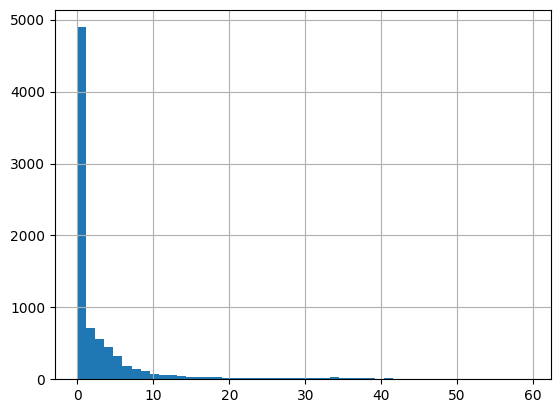

In [29]:
features['days_to_decay_min'].hist(bins=50)

In [30]:
features.describe()

,NORAD_CAT_ID,MEAN_MOTION_last,MEAN_MOTION_std,bstar_log_last,bstar_log_mean,bstar_log_std,altitude_avg_last,altitude_range_last,ECCENTRICITY_last,INCLINATION_last,MEAN_MOTION_DOT_mean,days_to_decay_min
count,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00,8172.00
mean,46577.13,16.00,0.19,0.01,0.01,0.00,406.77,329.98,0.01,76.25,0.01,3.69
std,9201.64,0.86,0.33,0.04,0.02,0.01,4306.76,8327.61,0.04,21.70,0.02,7.76
min,233.00,0.08,0.00,-0.36,-0.00,0.00,-34.21,0.01,0.00,0.05,-0.01,0.00
25%,43210.50,15.89,0.11,0.00,0.00,0.00,182.09,10.72,0.00,53.04,0.00,0.17
50%,47971.00,16.21,0.14,0.00,0.00,0.00,216.39,16.69,0.00,82.55,0.01,0.61
75%,51604.25,16.34,0.17,0.01,0.01,0.00,304.70,28.22,0.00,97.35,0.01,3.50
max,68320.00,17.18,7.12,1.45,0.45,0.47,220769.79,402826.13,0.97,146.00,0.49,59.37


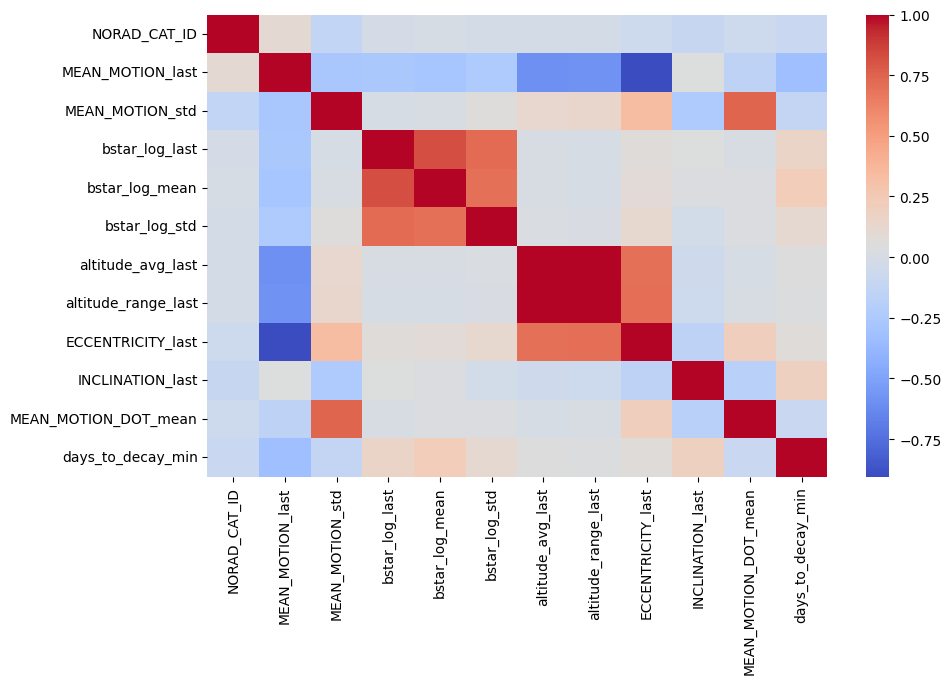

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(features.corr(), cmap='coolwarm')
plt.show()

In [32]:
import pandas as pd

file_path = r"C:\Users\dell\Desktop\newfolder\discos_objects.csv"
discos = pd.read_csv(file_path)



C:\Users\dell\AppData\Local\Temp\ipykernel_12192\790082684.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  discos = pd.read_csv(file_path)


In [33]:
def recategorize_object_class(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.strip()
    
    if x == "Payload":
        return "PAYLOAD"
    
    elif x == "Rocket Body":
        return "ROCKET_BODY"
    
    elif x in [
        "Payload Fragmentation Debris",
        "Rocket Fragmentation Debris",
        "Payload Debris",
        "Rocket Debris",
        "Other Debris"
    ]:
        return "DEBRIS"
    
    elif x in [
        "Payload Mission Related Object",
        "Rocket Mission Related Object"
    ]:
        return "MISSION_OBJECT"
    
    else:
        return "UNKNOWN"

In [34]:
import pandas as pd

discos['objectClass_grouped'] = discos['objectClass'].apply(recategorize_object_class)

In [35]:
discos['objectClass_grouped'].value_counts()

objectClass_grouped
DEBRIS            32275
PAYLOAD           27197
UNKNOWN           13582
ROCKET_BODY        8532
MISSION_OBJECT     8288
Name: count, dtype: int64

In [36]:
df_discos_small = discos[['satno', 'objectClass_grouped']].copy()

In [37]:
df_discos_small = df_discos_small.rename(columns={
    'satno': 'NORAD_CAT_ID'
})

---
## 🔀 Section 10 — One-Hot Encoding & Target Transformation

Encode `objectClass_grouped` as dummy variables, drop the UNKNOWN class, apply a log1p transform to the skewed target, and inspect the resulting class distribution.

In [38]:
print("Features IDs:", features['NORAD_CAT_ID'].nunique())
print("DISCOS IDs:", df_discos_small['NORAD_CAT_ID'].nunique())

common = set(features['NORAD_CAT_ID']) & set(df_discos_small['NORAD_CAT_ID'])
print("Common IDs:", len(common))

Features IDs: 8172
DISCOS IDs: 68257
Common IDs: 8169


In [39]:
features = features.merge(
    df_discos_small,
    on='NORAD_CAT_ID',
    how='left'
)

In [40]:
features['objectClass_grouped'].isna().sum()

3

In [41]:
features = pd.get_dummies(
    features,
    columns=['objectClass_grouped'],
    dummy_na=True
)

In [42]:
features.columns


Index(['NORAD_CAT_ID', 'MEAN_MOTION_last', 'MEAN_MOTION_std', 'bstar_log_last',
       'bstar_log_mean', 'bstar_log_std', 'altitude_avg_last',
       'altitude_range_last', 'ECCENTRICITY_last', 'INCLINATION_last',
       'MEAN_MOTION_DOT_mean', 'days_to_decay_min',
       'objectClass_grouped_DEBRIS', 'objectClass_grouped_MISSION_OBJECT',
       'objectClass_grouped_PAYLOAD', 'objectClass_grouped_ROCKET_BODY',
       'objectClass_grouped_UNKNOWN', 'objectClass_grouped_nan'],
      dtype='object')

In [43]:
features = features.drop(columns=['objectClass_grouped_nan'])

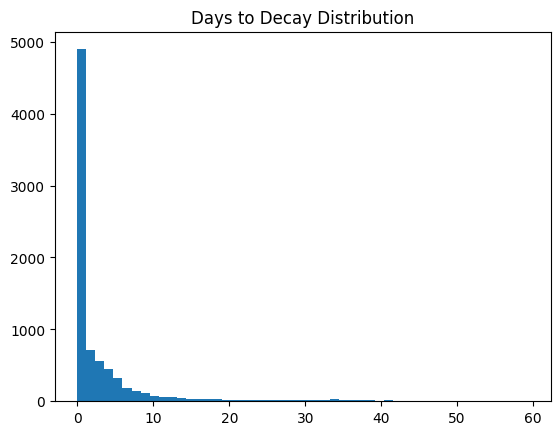

In [44]:
import matplotlib.pyplot as plt

plt.hist(features['days_to_decay_min'], bins=50)
plt.title("Days to Decay Distribution")
plt.show()

In [45]:
features.groupby([
    'objectClass_grouped_DEBRIS',
    'objectClass_grouped_PAYLOAD',
    'objectClass_grouped_ROCKET_BODY'
])['days_to_decay_min'].mean()

objectClass_grouped_DEBRIS  objectClass_grouped_PAYLOAD  objectClass_grouped_ROCKET_BODY
False                       False                        False                             1.50
                                                         True                              0.53
                            True                         False                             1.20
True                        False                        False                             6.76
Name: days_to_decay_min, dtype: float64

In [46]:
features.groupby([
    'objectClass_grouped_DEBRIS',
    'objectClass_grouped_PAYLOAD',
    'objectClass_grouped_ROCKET_BODY'
])['days_to_decay_min'].mean()

objectClass_grouped_DEBRIS  objectClass_grouped_PAYLOAD  objectClass_grouped_ROCKET_BODY
False                       False                        False                             1.50
                                                         True                              0.53
                            True                         False                             1.20
True                        False                        False                             6.76
Name: days_to_decay_min, dtype: float64

In [47]:
import numpy as np

features['target_log'] = np.log1p(features['days_to_decay_min'])

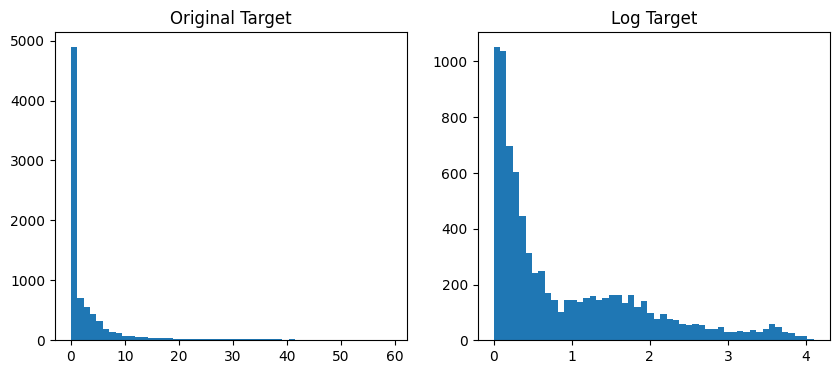

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(features['days_to_decay_min'], bins=50)
plt.title("Original Target")

plt.subplot(1,2,2)
plt.hist(features['target_log'], bins=50)
plt.title("Log Target")

plt.show()

In [49]:
features.filter(like='objectClass_grouped').sum()

objectClass_grouped_DEBRIS            3667
objectClass_grouped_MISSION_OBJECT     680
objectClass_grouped_PAYLOAD           3386
objectClass_grouped_ROCKET_BODY        427
objectClass_grouped_UNKNOWN              9
dtype: int64

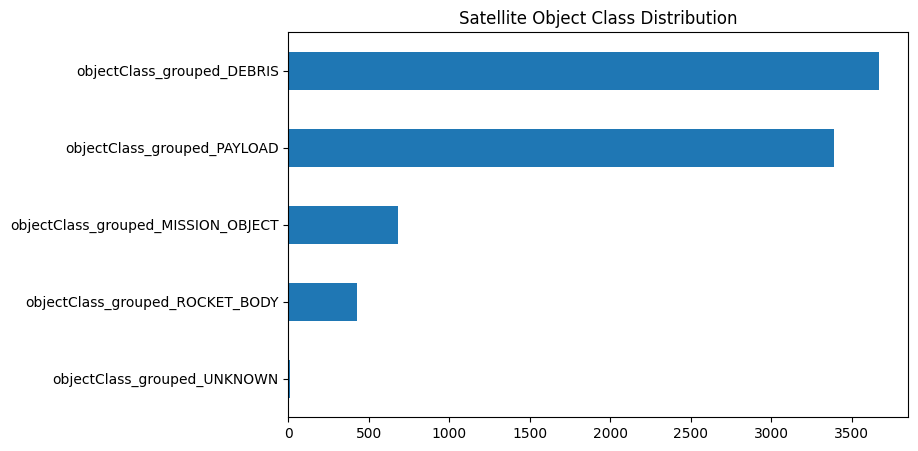

In [50]:
import matplotlib.pyplot as plt

obj_cols = features.filter(like='objectClass_grouped').columns

counts = features[obj_cols].sum().sort_values()

plt.figure(figsize=(8,5))
counts.plot(kind='barh')
plt.title("Satellite Object Class Distribution")
plt.show()

---
## 🤖 Section 11 — Prepare Feature Matrix

Drop satellites with unknown object class, then define `X`, `y`, and `groups` ready for modelling.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import pickle, json

# Drop satellites with unknown object class
features = features[features['objectClass_grouped_UNKNOWN'] == 0].copy()
features = features.drop(columns=['objectClass_grouped_UNKNOWN'])

# Define features, target, and groups (one group = one satellite)
X      = features.drop(columns=['NORAD_CAT_ID', 'days_to_decay_min', 'target_log'])
y      = features['days_to_decay_min']
groups = features['NORAD_CAT_ID']

print('Feature matrix shape:', X.shape)
print('Feature columns:', list(X.columns))

Feature matrix shape: (8163, 14)
Feature columns: ['MEAN_MOTION_last', 'MEAN_MOTION_std', 'bstar_log_last', 'bstar_log_mean', 'bstar_log_std', 'altitude_avg_last', 'altitude_range_last', 'ECCENTRICITY_last', 'INCLINATION_last', 'MEAN_MOTION_DOT_mean', 'objectClass_grouped_DEBRIS', 'objectClass_grouped_MISSION_OBJECT', 'objectClass_grouped_PAYLOAD', 'objectClass_grouped_ROCKET_BODY']


---
## 📉 Section 12 — Cross-Validation (GroupKFold, 5 folds)

5-fold cross-validation for both models. Each fold uses a different set of satellites for testing. Averaging the 5 scores gives a reliable, honest estimate of model performance.

In [52]:
gkf = GroupKFold(n_splits=5)

# ── Random Forest ─────────────────────────────────────────────────────
rf_r2, rf_mae = [], []
rf_y_test_all, rf_preds_all = [], []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    _rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    _rf.fit(X_tr, y_tr)
    preds = _rf.predict(X_te)

    rf_r2.append(r2_score(y_te, preds))
    rf_mae.append(mean_absolute_error(y_te, preds))
    rf_y_test_all.extend(y_te)
    rf_preds_all.extend(preds)

print(f'Random Forest  →  R²: {np.mean(rf_r2):.4f} ± {np.std(rf_r2):.4f}  |  MAE: {np.mean(rf_mae):.4f} ± {np.std(rf_mae):.4f} days')

# ── XGBoost ───────────────────────────────────────────────────────────
xgb_r2, xgb_mae = [], []
xgb_y_test_all, xgb_preds_all = [], []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    _xgb = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42
    )
    _xgb.fit(X_tr, y_tr)
    preds = _xgb.predict(X_te)

    xgb_r2.append(r2_score(y_te, preds))
    xgb_mae.append(mean_absolute_error(y_te, preds))
    xgb_y_test_all.extend(y_te)
    xgb_preds_all.extend(preds)

print(f'XGBoost        →  R²: {np.mean(xgb_r2):.4f} ± {np.std(xgb_r2):.4f}  |  MAE: {np.mean(xgb_mae):.4f} ± {np.std(xgb_mae):.4f} days')

Random Forest  →  R²: 0.8578 ± 0.0138  |  MAE: 1.4869 ± 0.0498 days
XGBoost        →  R²: 0.8651 ± 0.0191  |  MAE: 1.4559 ± 0.0539 days


---
## 📊 Section 13 — Results Comparison

Side-by-side summary of both models so it's immediately clear which one performed better.

In [53]:
results = pd.DataFrame({
    'Model':  ['Random Forest', 'XGBoost'],
    'R²':     [round(np.mean(rf_r2), 4),  round(np.mean(xgb_r2), 4)],
    'R² std': [round(np.std(rf_r2), 4),   round(np.std(xgb_r2), 4)],
    'MAE (days)': [round(np.mean(rf_mae), 4), round(np.mean(xgb_mae), 4)],
    'MAE std':    [round(np.std(rf_mae), 4),  round(np.std(xgb_mae), 4)],
})

print(results.to_string(index=False))

best = 'XGBoost' if np.mean(xgb_r2) > np.mean(rf_r2) else 'Random Forest'
print(f'\n✅ Best model: {best}')

        Model   R²  R² std  MAE (days)  MAE std
Random Forest 0.86    0.01        1.49     0.05
      XGBoost 0.87    0.02        1.46     0.05

✅ Best model: XGBoost


---
## 📈 Section 14 — Feature Importance

Which features actually drove the predictions? Shown for both models.

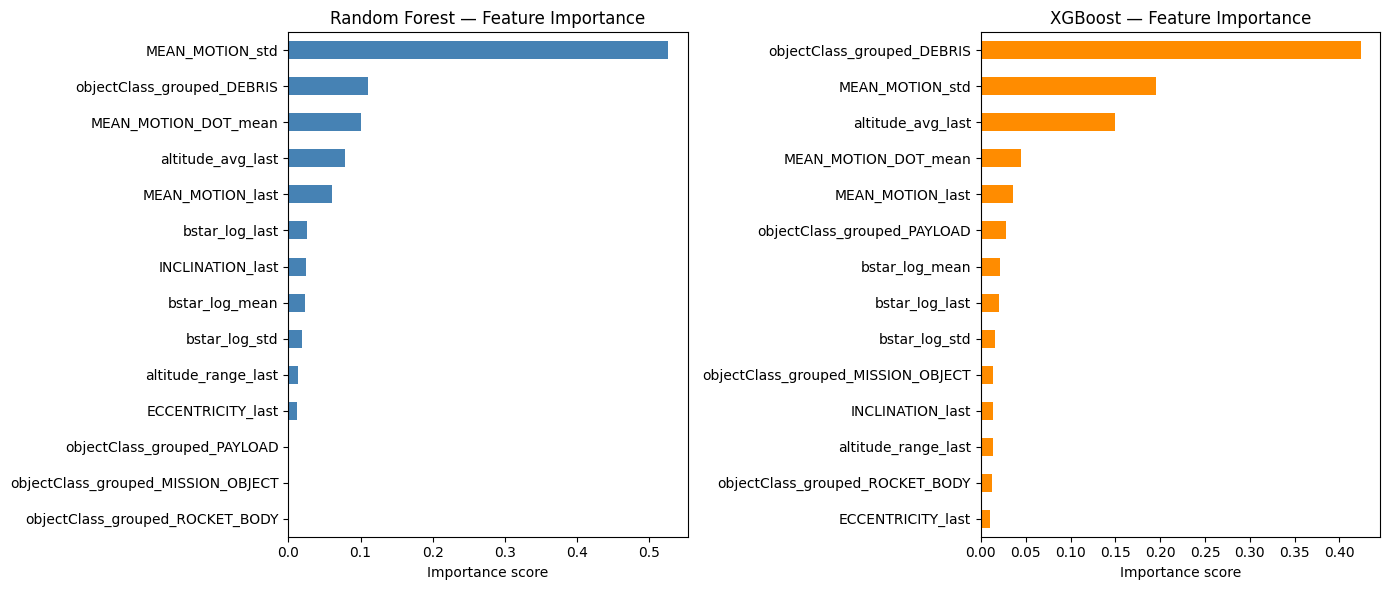

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest importance (from last fold model)
rf_imp = pd.Series(_rf.feature_importances_, index=X.columns).sort_values()
rf_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance score')

# XGBoost importance (from last fold model)
xgb_imp = pd.Series(_xgb.feature_importances_, index=X.columns).sort_values()
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

---
## 🎯 Section 15 — Actual vs Predicted

Scatter plot of true vs predicted decay days across all 5 folds. Points on the diagonal line = perfect prediction. Shows where each model is accurate and where it struggles.

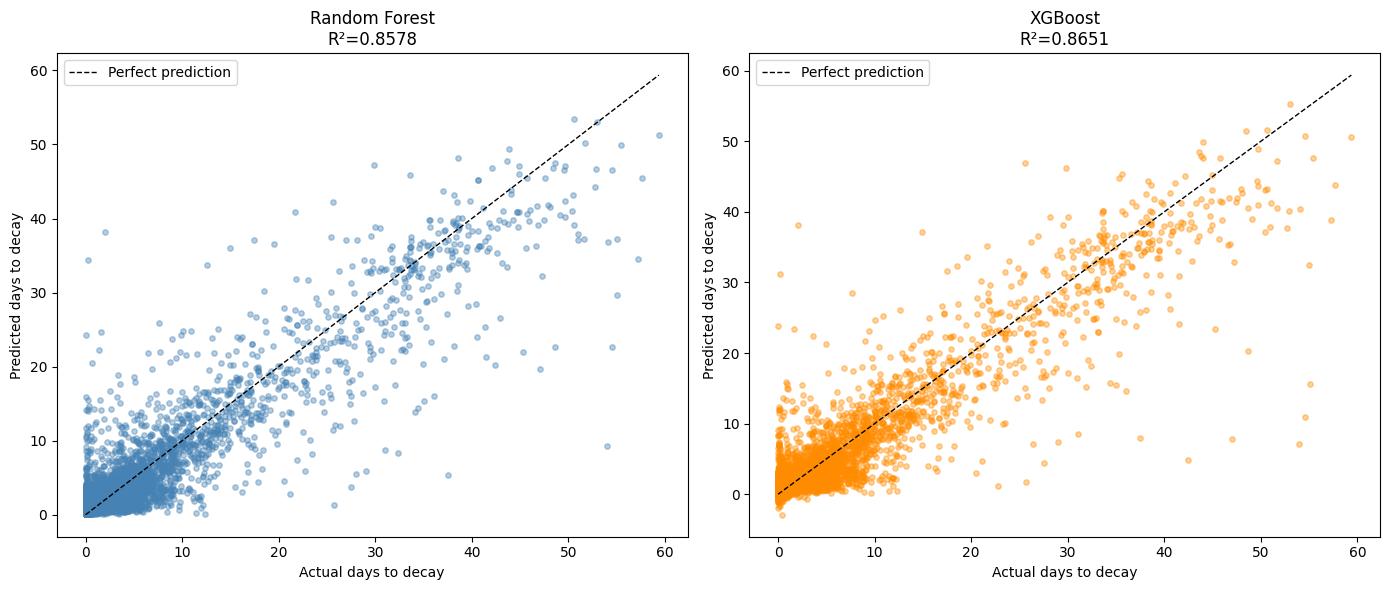

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, title, color in zip(
    axes,
    [rf_y_test_all,  xgb_y_test_all],
    [rf_preds_all,   xgb_preds_all],
    ['Random Forest', 'XGBoost'],
    ['steelblue',    'darkorange']
):
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color=color)
    max_val = max(max(y_true), max(y_pred))
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual days to decay')
    ax.set_ylabel('Predicted days to decay')
    ax.set_title(f'{title}\nR²={np.mean(rf_r2 if title=="Random Forest" else xgb_r2):.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 🏆 Section 16 — Train Final Models on All Data & Save

Cross-validation above was only for measuring performance. Now we train on 100% of the data so the saved models are as strong as possible.

In [56]:
# Train on full dataset
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42
)
xgb_model.fit(X, y)

# Save models + metadata
with open('rf_model.pkl',  'wb') as f: pickle.dump(rf_model,  f)
with open('xgb_model.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('feature_columns.json', 'w') as f: json.dump(X.columns.tolist(), f)
with open('model_metrics.json', 'w') as f:
    json.dump({
        'rf':  {'r2': float(np.mean(rf_r2)),  'mae': float(np.mean(rf_mae))},
        'xgb': {'r2': float(np.mean(xgb_r2)), 'mae': float(np.mean(xgb_mae))}
    }, f, indent=2)

print('✅ Saved: rf_model.pkl, xgb_model.pkl, feature_columns.json, model_metrics.json')
print(f'   Features: {len(X.columns)}  |  Training rows: {len(X)}')

✅ Saved: rf_model.pkl, xgb_model.pkl, feature_columns.json, model_metrics.json
   Features: 14  |  Training rows: 8163


---
## 🛰️ Section 17 — Predict on a Custom Satellite

Define one satellite's orbital parameters manually and run it through both models. Edit the values below to simulate any satellite you like.

In [57]:
# Define a custom satellite's orbital parameters
# Edit these values to simulate different satellites
custom_satellite = {
    'mean_motion_last':   15.5,    # revolutions per day  (ISS ~ 15.5)
    'mean_motion_std':     0.001,  # how stable the orbit has been
    'bstar_log_last':      0.01,   # atmospheric drag (log scale)
    'bstar_log_mean':      0.009,
    'bstar_log_std':       0.002,
    'altitude_avg_last':  380.0,   # average altitude in km
    'altitude_range_last': 20.0,   # apoapsis - periapsis in km
    'ecc_last':            0.001,  # eccentricity (0 = circular)
    'inc_last':           51.6,    # inclination in degrees
    'mean_motion_dot_mean': 0.0001,# rate of orbital decay
    'objectClass_grouped_DEBRIS':       0,
    'objectClass_grouped_PAYLOAD':      1,
    'objectClass_grouped_ROCKET_BODY':  0,
}

# Align with training columns (fill any missing with 0)
custom_df = pd.DataFrame([custom_satellite])
custom_df = custom_df.reindex(columns=X.columns, fill_value=0)

rf_pred  = rf_model.predict(custom_df)[0]
xgb_pred = xgb_model.predict(custom_df)[0]

print('── Custom Satellite Prediction ──')
print(f'  Random Forest  : {rf_pred:.2f} days until re-entry')
print(f'  XGBoost        : {xgb_pred:.2f} days until re-entry')
print(f'  Average        : {(rf_pred + xgb_pred) / 2:.2f} days until re-entry')

── Custom Satellite Prediction ──
  Random Forest  : 10.41 days until re-entry
  XGBoost        : 15.88 days until re-entry
  Average        : 13.15 days until re-entry
